# Evaluation Metrics Lab 


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Classification (Heart Disease Dataset)

In [19]:
# Load dataset 

heart_disease = pd.read_csv("heart-disease.csv")

heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_preds = model.predict(X_test)

confusion_matrix(y_test, y_preds)

array([[22,  5],
       [ 4, 30]])

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_preds)
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8524590163934426
Precision: 0.8571428571428571
Recall: 0.8823529411764706
F1 Score: 0.8695652173913043


##### Interpretation

Accuracy = 85%
The model correctly predicted 82% of patients.

Precision =
Out of all patients predicted as diseased, 82% actually had heart disease.

Recall = 88%
The model successfully identified 89% of actual heart disease patients.

F1 Score = 8%
The model maintains a good balance between precision and recall.

Overall, the model shows strong classification performance.

In [5]:
# Confusion Matrix
confusion_matrix(y_test, y_preds)

array([[18, 11],
       [ 2, 30]])

In [6]:
# Classification Report
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.90      0.62      0.73        29
           1       0.73      0.94      0.82        32

    accuracy                           0.79        61
   macro avg       0.82      0.78      0.78        61
weighted avg       0.81      0.79      0.78        61



Precision = correctness of positive predictions.
Recall = how many actual positives we captured.

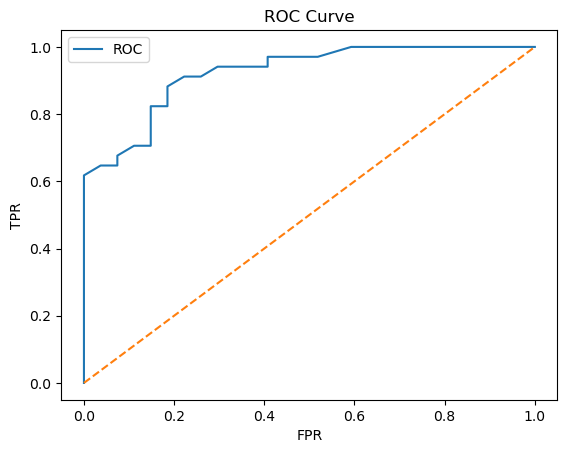

In [24]:
# ROC Curve
y_probs = model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="ROC")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
# AUC Score
roc_auc_score(y_test, y_probs)

0.9237472766884531

In [26]:
from sklearn.metrics import precision_score, recall_score

y_probs = model.predict_proba(X_test)[:, 1]

y_preds_05 = (y_probs >= 0.5).astype(int)
y_preds_07 = (y_probs >= 0.7).astype(int)

print("Threshold = 0.5")
print("Precision:", precision_score(y_test, y_preds_05))
print("Recall:", recall_score(y_test, y_preds_05))

print("\nThreshold = 0.7")
print("Precision:", precision_score(y_test, y_preds_07))
print("Recall:", recall_score(y_test, y_preds_07))

Threshold = 0.5
Precision: 0.8571428571428571
Recall: 0.8823529411764706

Threshold = 0.7
Precision: 0.9565217391304348
Recall: 0.6470588235294118


##### 8. Explain When Precision is More Important 

In the Heart Disease Dataset, precision becomes more important when we want to avoid falsely predicting heart disease in healthy patients.

##### 9. Explain When Recall is More Important 

In the Heart Disease Dataset, recall becomes more important when missing a patient with heart disease is dangerous.

## Regression Task (Boston Housing Dataset)

In [9]:
# Load dataset (ensure CSV available or use sklearn alternative)
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8189298832757234

R² shows how much variation is explained.

In [11]:
# MAE
y_preds = model.predict(X_test)
mean_absolute_error(y_test, y_preds)

0.33587167458817846

In [12]:
# MSE
mean_squared_error(y_test, y_preds)

0.2576102485518876

In [13]:
# R²
r2_score(y_test, y_preds)

0.8189298832757234

### Comparison
MAE treats all errors equally.

MSE gives more importance to large errors.

R² measures how well the model explains the data overall.